In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix
)

In [3]:
# Column names (41 features + label + difficulty)
col_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv(
    r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\nsl-kdd\KDDTrain+.txt", 
    names=col_names, sep=","
)
test_df = pd.read_csv(
    r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\nsl-kdd\KDDTest+.txt", 
    names=col_names, sep=","
)

In [4]:
# Remove periods from labels
train_df["label"] = train_df["label"].astype(str).str.replace('.', '', regex=False)
test_df["label"] = test_df["label"].astype(str).str.replace('.', '', regex=False)

# Drop 'difficulty'
train_df = train_df.drop(columns=["difficulty"])
test_df = test_df.drop(columns=["difficulty"])

# Binary labels
train_df["binary_label"] = train_df["label"].apply(lambda x: "normal" if x == "normal" else "attack")
test_df["binary_label"] = test_df["label"].apply(lambda x: "normal" if x == "normal" else "attack")

In [5]:
# Features
X_train = train_df.drop(columns=["label", "binary_label"])
X_test = test_df.drop(columns=["label", "binary_label"])

# Binary classification labels
y_train_bin = train_df["binary_label"]
y_test_bin = test_df["binary_label"]

# Multi-class labels
y_train_multi = train_df["label"]
y_test_multi = test_df["label"]

In [6]:
# Categorical and numeric columns
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [col for col in X_train.columns if col not in cat_cols]

In [7]:
# Preprocessor: scale numeric and one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [8]:
def evaluate_classification(true, pred):
    acc = accuracy_score(true, pred)
    prec = precision_score(true, pred, average='weighted', zero_division=0)
    rec = recall_score(true, pred, average='weighted', zero_division=0)
    f1 = f1_score(true, pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

===== Binary Classification (Normal vs Attack) =====

Logistic Regression
              precision    recall  f1-score   support

      attack       0.92      0.62      0.74     12833
      normal       0.65      0.93      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



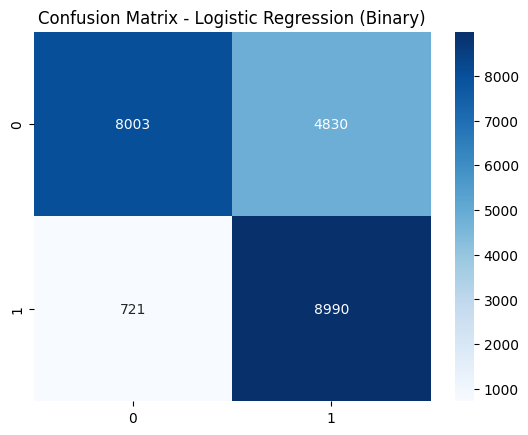


K-Nearest Neighbors
              precision    recall  f1-score   support

      attack       0.97      0.64      0.77     12833
      normal       0.67      0.97      0.79      9711

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



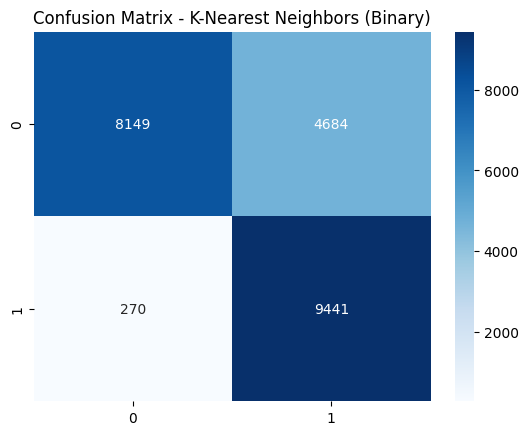


Decision Tree
              precision    recall  f1-score   support

      attack       0.96      0.65      0.77     12833
      normal       0.68      0.97      0.80      9711

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



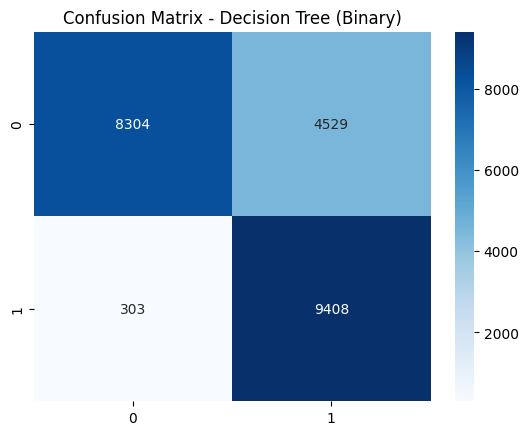


Random Forest
              precision    recall  f1-score   support

      attack       0.97      0.61      0.75     12833
      normal       0.65      0.97      0.78      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



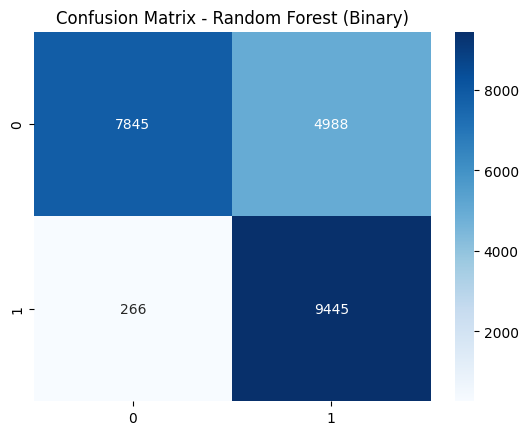


SVM
              precision    recall  f1-score   support

      attack       0.96      0.62      0.76     12833
      normal       0.66      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



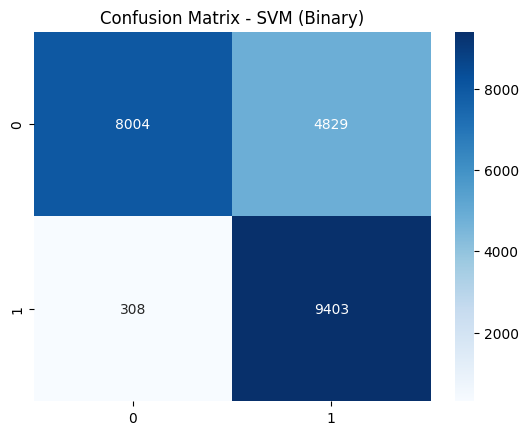


AdaBoost
              precision    recall  f1-score   support

      attack       0.96      0.61      0.75     12833
      normal       0.65      0.97      0.78      9711

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



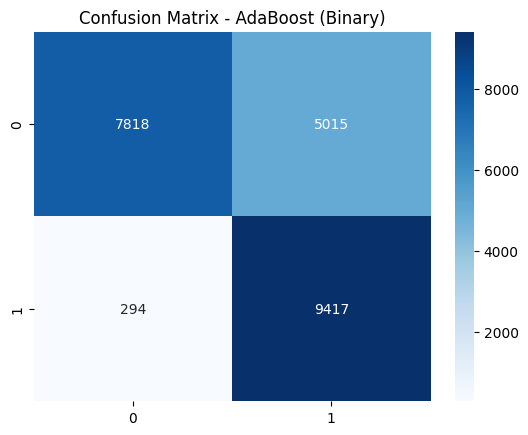


Binary Classification Summary:
                 Model  Accuracy  Precision    Recall        F1
2        Decision Tree  0.785664   0.839980  0.785664  0.783691
1  K-Nearest Neighbors  0.780252   0.838900  0.780252  0.777778
4                  SVM  0.772134   0.832748  0.772134  0.769288
3        Random Forest  0.766945   0.832463  0.766945  0.763463
5             AdaBoost  0.764505   0.829684  0.764505  0.760989
0  Logistic Regression  0.753770   0.802408  0.753770  0.751802


In [10]:
print("===== Binary Classification (Normal vs Attack) =====")

model_list_bin = []
acc_list_bin, prec_list_bin, rec_list_bin, f1_list_bin = [], [], [], []

for name, model in models.items():
    model.fit(X_train_processed, y_train_bin)
    y_pred = model.predict(X_test_processed)

    acc, prec, rec, f1 = evaluate_classification(y_test_bin, y_pred)

    print(f"\n{name}")
    print(classification_report(y_test_bin, y_pred))

    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Binary)')
    plt.show()

    model_list_bin.append(name)
    acc_list_bin.append(acc)
    prec_list_bin.append(prec)
    rec_list_bin.append(rec)
    f1_list_bin.append(f1)

summary_bin = pd.DataFrame({
    "Model": model_list_bin,
    "Accuracy": acc_list_bin,
    "Precision": prec_list_bin,
    "Recall": rec_list_bin,
    "F1": f1_list_bin
})

print("\nBinary Classification Summary:")
print(summary_bin.sort_values(by="Accuracy", ascending=False))

In [11]:
print("===== Multi-Class Classification =====")

model_list_multi = []
acc_list_multi, prec_list_multi, rec_list_multi, f1_list_multi = [], [], [], []

for name, model in models.items():
    model.fit(X_train_processed, y_train_multi)
    y_pred = model.predict(X_test_processed)

    acc, prec, rec, f1 = evaluate_classification(y_test_multi, y_pred)

    print(f"\n{name}")
    print(classification_report(y_test_multi, y_pred, zero_division=0))


    model_list_multi.append(name)
    acc_list_multi.append(acc)
    prec_list_multi.append(prec)
    rec_list_multi.append(rec)
    f1_list_multi.append(f1)

summary_multi = pd.DataFrame({
    "Model": model_list_multi,
    "Accuracy": acc_list_multi,
    "Precision": prec_list_multi,
    "Recall": rec_list_multi,
    "F1": f1_list_multi
})

print("\nMulti-Class Classification Summary:")
print(summary_multi.sort_values(by="Accuracy", ascending=False))

===== Multi-Class Classification =====

Logistic Regression
                 precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.82      0.62      0.71       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.74      0.97      0.84       141
           land       1.00      1.00      1.00         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.96      1.00      0.98      4657
           nmap       0.39 